In [13]:
import numpy as np 
import matplotlib.pyplot as plt

In [48]:
def nnmf(X,k):
    '''
    X: 2D np array- The matrix where each column represents a sample point, and each row represent a dimension in the samples. 
    k: int - Number of factors to calculate.
    '''
    M=X.shape[0]
    N=X.shape[1]
    w=np.random.rand(M,k)
    h=np.random.rand(k,N)

    eps=1e-6

    for i in range(300):
        w= w*((X/(w@h+eps)@h.T)/(np.sum(h,axis=1)+eps))

        h=h*((w.T@((X)/(w@h+eps)))/(np.sum(w,axis=0)[:,None]+eps))#weird [:,None] is for broadcasting to make the sum of w a column vector instead of a row vector.

    return w,h

Process the Video 

In [49]:
import cv2 

video_data=cv2.VideoCapture("snare.MOV")
video_w=int(video_data.get(cv2.CAP_PROP_FRAME_WIDTH))
video_h=int(video_data.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_frames=int(video_data.get(cv2.CAP_PROP_FRAME_COUNT))
fps=int(video_data.get(cv2.CAP_PROP_FPS))
new_w= 50
new_h= int(new_w*video_h/video_w)
print(new_w,new_h,fps)
frames=[]

#We use this method instead of frame count becuase some people report issues. 
#https://github.com/opencv/opencv/issues/16821 
while video_data.isOpened():
    ret, frame= video_data.read()
    if not ret:
        break
    ds_frame=cv2.resize(frame,(new_w,new_h))
    gray=cv2.cvtColor(ds_frame,cv2.COLOR_BGR2GRAY)
    frames.append(gray.flatten(order="F"))

X=np.array(frames).T

print(X.shape)

50 28 30
(1400, 207)


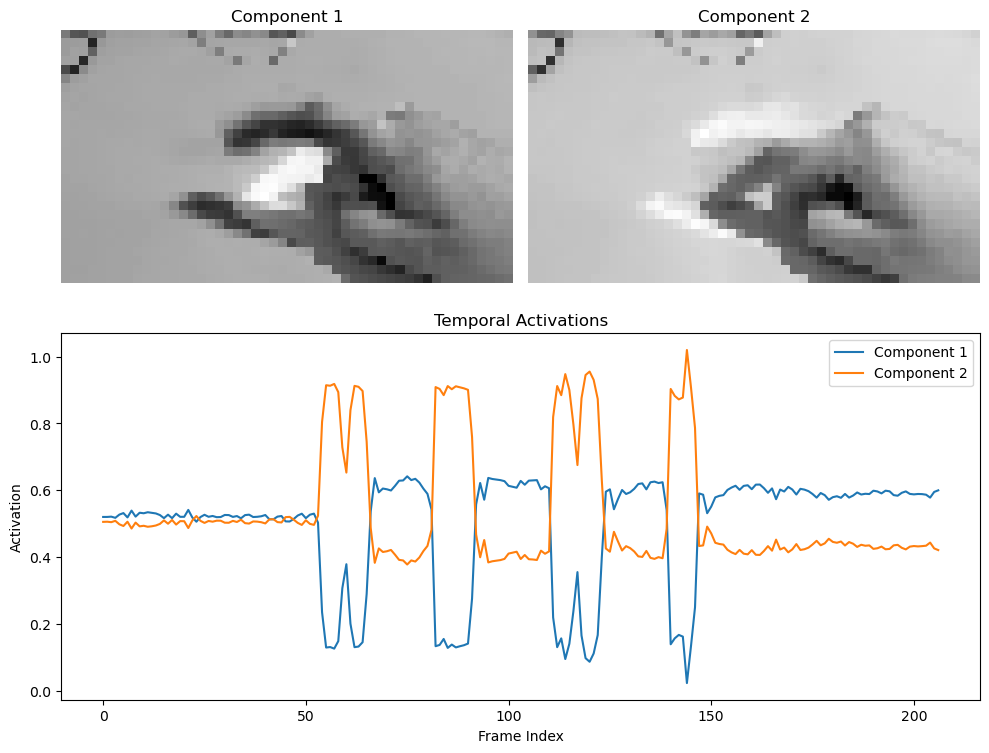

In [50]:
nnmf_w,nnmf_h=nnmf(X,2)

image_1=nnmf_w[:,0].reshape((new_h,new_w),order="F")
image_2=nnmf_w[:,1].reshape((new_h,new_w),order="F")

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(image_1, cmap="gray")
plt.title("Component 1")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(image_2, cmap="gray")
plt.title("Component 2")
plt.axis("off")

plt.subplot(2,1,2)
plt.plot(nnmf_h[0,:], label="Component 1")
plt.plot(nnmf_h[1,:], label="Component 2")
plt.title("Temporal Activations")
plt.xlabel("Frame Index")
plt.ylabel("Activation")
plt.legend()

plt.tight_layout()
plt.show()

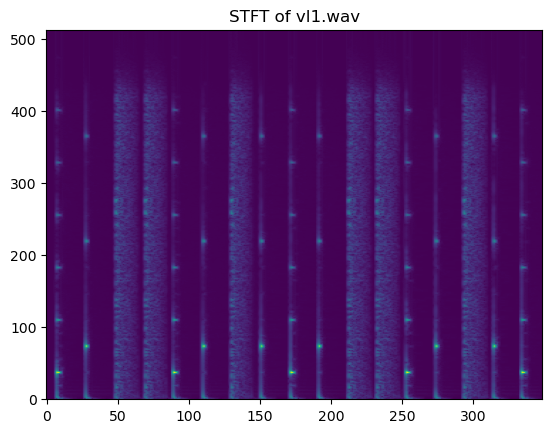

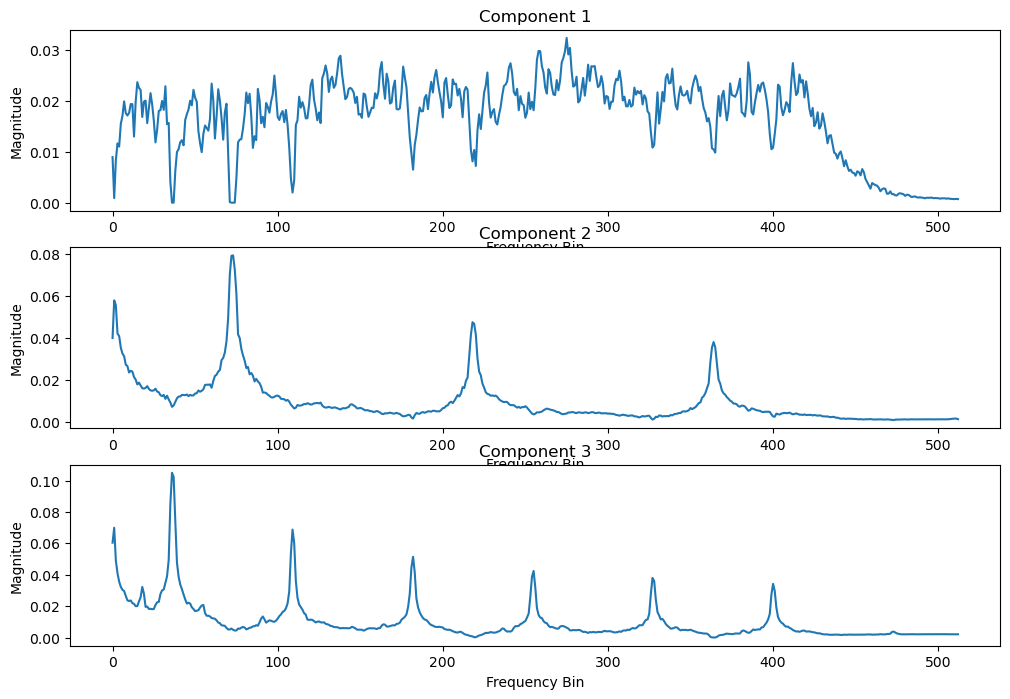

In [6]:
import librosa
import scipy.signal as signal

x, sr=librosa.load("vl1.wav",sr=None,mono=True)
_, _, stft = signal.stft(x, fs=sr, window='hamming', nperseg=1024, noverlap=768)
stft_mag_log=np.abs(stft)**.5
plt.imshow(stft_mag_log,origin="lower", aspect="auto")
plt.title("STFT of vl1.wav")


audio_w_nnmf, audio_h_nnmf = nnmf(stft_mag_log, 3)
plt.figure(figsize=(12,8))
for i in range(3):
    plt.subplot(3,1,i+1)
    plt.plot(audio_w_nnmf[:,i])
    plt.title(f"Component {i+1}")
    plt.xlabel("Frequency Bin")
    plt.ylabel("Magnitude")

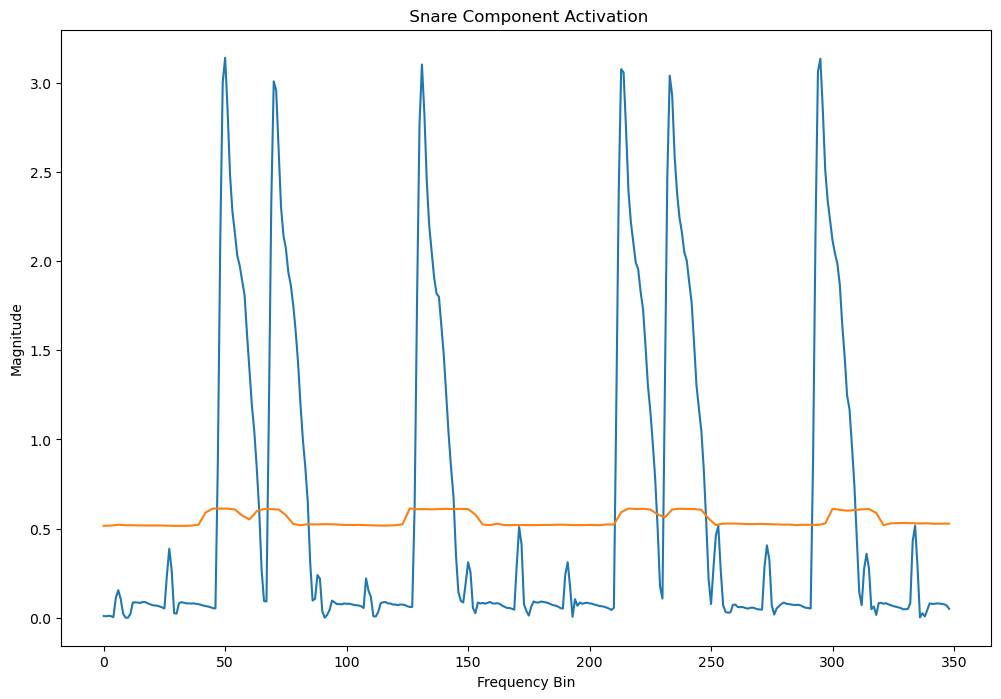

In [23]:
plt.figure(figsize=(12,8))
plt.plot(audio_h_nnmf[0,:])

cropped=nnmf_h[0,40:-50]
original_len = len(cropped)
target_len   = len(audio_h_nnmf[0,:])

x_new = np.linspace(0, original_len - 1, target_len)
x_old = np.arange(original_len)

nnmf_h_upscaled = np.interp(x_new, x_old, cropped)

plt.plot(nnmf_h_upscaled)
plt.title(" Snare Component Activation")
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude")
plt.show()


In [ ]:
import soundfile as sf
snare_stft=audio_w_nnmf[:,1:2]@ audio_h_nnmf[1:2,:]
snare_audio= signal.istft(snare_stft, fs=sr, window='hamming', nperseg=1024, noverlap=768)[1]

sf.write("snare_component.wav", snare_audio, sr)